In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [4]:
fx=0.1
t_ini = -7
fullt=np.linspace(t_ini,30, 300)
teval=0
kref=1
supprshift=8
p=0
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=p, supprshift=supprshift)
def g_ank(k):
    return nk.g_an(-(2+p)*np.log(k/kref))
def h_ank(k):
    return nk.h_an(-(2+p)*np.log(k/kref))

def g_numk(k):
    return nk.g_num(-(2+p)*np.log(k/kref))
def h_numk(k):
    return nk.h_num(-(2+p)*np.log(k/kref))

---
$F^{[2]}_\chi (q,k-q)$

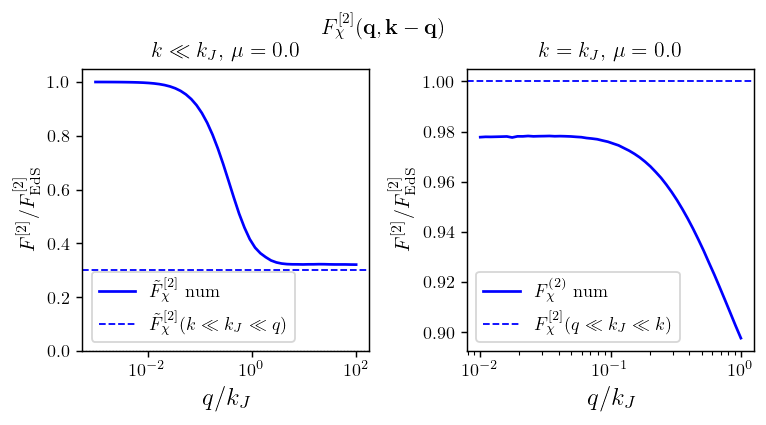

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-3
qlist=np.logspace(-3,2,50)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,_,F2x,_= nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_low.append([F2x,nk.F2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
ax1.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'b', label=r'$\tilde F_\chi^{[2]}$ num')
F2chi_qkMq_limB = 3/10
ax1.axhline(F2chi_qkMq_limB, color='b', linestyle='--', linewidth=1, label=r'$\tilde F_\chi^{[2]}(k\ll k_J \ll q$)')
ax1.axhline(0, color='k', linestyle=':', linewidth=0.7)
ax1.legend()
ax1.set_ylim([0.,None])
ax1.set_title(r'$k\ll k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax1.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_J$', fontsize=14)

kphigh=5
qlist=np.logspace(-2,0,50)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,_,F2x,_=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2x,g_ank(kphigh/kref)*nk.F2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high)

# Second plot
ax2.plot(qlist,Flist_high[:,0]/Flist_high[:,1], 'b', label=r'$F_\chi^{(2)}$ num')
ax2.axhline(1, color='b', linestyle='--', linewidth=1, label=r'$F_\chi^{[2]}(q\ll k_J \ll k$)')
ax2.legend()
ax2.set_title(r'$k= k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax2.set_xscale('log')
# ax2.set_ylim([-0.5,0.5])
ax2.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax2.set_xlabel(r'$q/k_J$', fontsize=14)
plt.suptitle(r'$F_\chi^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$',y=0.92)
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2chi_qkMq.pdf', bbox_inches='tight')
plt.show()

$F^{[2]}_c (q,k-q)$

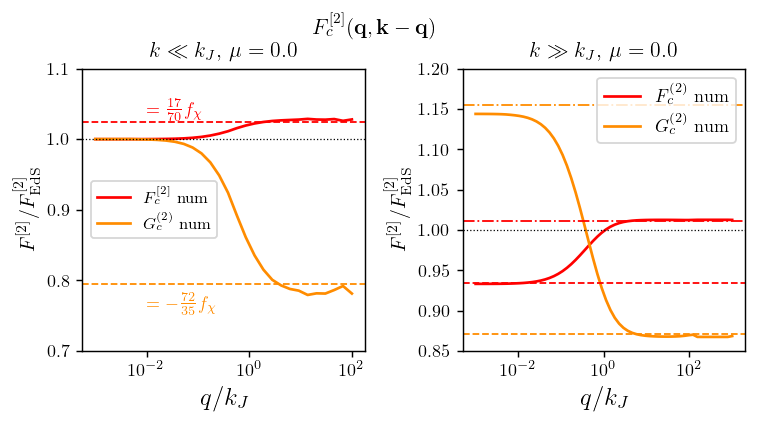

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-3
qlist=np.logspace(-3,2,30)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12])
    Flist_low.append([F2c,nk.F2_0(kplow,qp,mup), G2_c, nk.G2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
ax1.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'r', label=r'$F_c^{[2]}$ num')
ax1.plot(qlist,Flist_low[:,2]/Flist_low[:,3], 'darkorange', label=r'$G_c^{(2)}$ num')
DeltaF2c_qkMq_limB = (51*fx)/210
ax1.axhline(1+DeltaF2c_qkMq_limB, color='r', linestyle='--', linewidth=1)
ax1.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax1.axhline(1-72/35*fx, color='darkorange', linestyle='--', linewidth=1)

ax1.text(1.e-2, 1.035, r'$=\frac{17}{70}f_\chi$', color='r')
ax1.text(1.e-2, 0.76, r'$=-\frac{72}{35}f_\chi$', color='darkorange')
ax1.legend(fontsize=9, loc='center left')
ax1.set_ylim([0.7,1.1])
ax1.set_title(r'$k\ll k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax1.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_J$', fontsize=14)

kphigh=10
qlist=np.logspace(-3,3,60)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2c,nk.F2_0(kphigh,qp,mup), G2_c, nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high)

# Second plot
ax2.plot(qlist,Flist_high[:,0]/Flist_high[:,1], 'r', label=r'$F_c^{(2)}$ num')
ax2.plot(qlist,Flist_high[:,2]/Flist_high[:,3], 'darkorange', label=r'$G_c^{(2)}$ num')

DeltaF2c_qkMq_limD = -23/35*fx
ax2.axhline(1+DeltaF2c_qkMq_limD, color='r', linestyle='--', linewidth=1)
DeltaF2c_qkMq_limC = 4/35*fx
ax2.axhline(1+DeltaF2c_qkMq_limC, color='r', linestyle='-.', linewidth=1)
ax2.axhline(1+54/35*fx, color='darkorange', linestyle='-.', linewidth=1)
ax2.axhline(1-9/7*fx, color='darkorange', linestyle='--', linewidth=1)

ax2.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax2.legend()
ax2.set_title(r'$k\gg k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax2.set_xscale('log')
ax2.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax2.set_xlabel(r'$q/k_J$', fontsize=14)
ax2.set_ylim([0.85,1.2])

plt.suptitle(r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$',y=0.92)
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2c_qkMq.pdf', bbox_inches='tight')
plt.show()

----
plots for paper

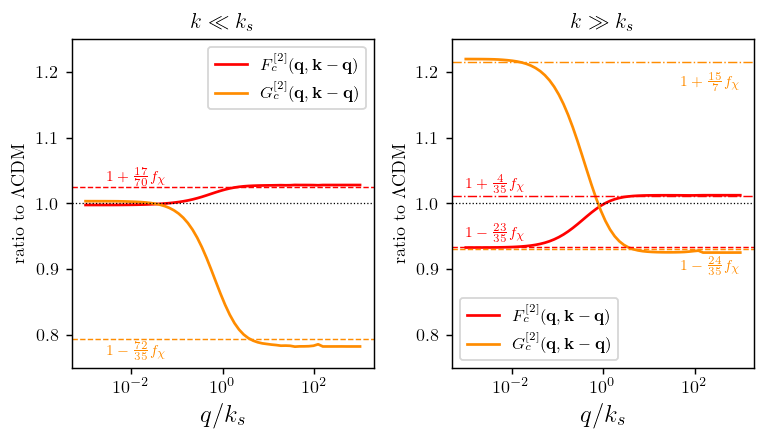

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1/21
qlist=np.logspace(-3,3,60)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12])
    Flist_low.append([F2c,nk.F2_0(kplow,qp,mup), G2_c, nk.g_c_int(-(2+p)*np.log(kplow/kref))*nk.G2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
ax1.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'r', label=r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
ax1.plot(qlist,Flist_low[:,2]/Flist_low[:,3], 'darkorange', label=r'$G_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
DeltaF2c_qkMq_limB = (51*fx)/210
ax1.axhline(1+DeltaF2c_qkMq_limB, color='r', linestyle='--', linewidth=0.8)
ax1.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax1.axhline(1-72/35*fx, color='darkorange', linestyle='--', linewidth=0.8)

ax1.text(3.e-3, 1.035, r'$1+\frac{17}{70}f_\chi$', color='r', fontsize=8)
ax1.text(3.e-3, 0.77, r'$1-\frac{72}{35}f_\chi$', color='darkorange', fontsize=8)
ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylim([0.75,1.25])
ax1.set_title(r'$k\ll k_s$')
ax1.set_ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_s$', fontsize=14)

kphigh=20
qlist=np.logspace(-3,3,60)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2c,nk.F2_0(kphigh,qp,mup), G2_c, nk.g_c_int(-(2+p)*np.log(kphigh/kref))*nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high)

# Second plot
ax2.plot(qlist,Flist_high[:,0]/Flist_high[:,1], 'r', label=r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
ax2.plot(qlist,Flist_high[:,2]/Flist_high[:,3], 'darkorange', label=r'$G_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')

ax2.axhline(1-23/35*fx, color='r', linestyle='--', linewidth=0.8)
ax2.text(1.e-3, 0.95, r'$1-\frac{23}{35}f_\chi$', color='r', fontsize=8)

ax2.axhline(1+4/35*fx, color='r', linestyle='-.', linewidth=0.8)
ax2.text(1.e-3, 1.025, r'$1+\frac{4}{35}f_\chi$', color='r', fontsize=8)

ax2.axhline(1+15/7*fx, color='darkorange', linestyle='-.', linewidth=0.8)
ax2.text(5.e1, 1.18, r'$1+\frac{15}{7}f_\chi$', color='darkorange', fontsize=8)

ax2.axhline(1-24/35*fx, color='darkorange', linestyle='--', linewidth=0.8)
ax2.text(5.e1, 0.9, r'$1-\frac{24}{35}f_\chi$', color='darkorange', fontsize=8)

ax2.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax2.legend(fontsize=9, loc='lower left')
ax2.set_title(r'$k\gg k_s$')
ax2.set_xscale('log')
ax2.set_ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
ax2.set_xlabel(r'$q/k_s$', fontsize=14)
ax2.set_ylim([0.75,1.25])
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2c_qkMq.pdf', bbox_inches='tight')
plt.show()

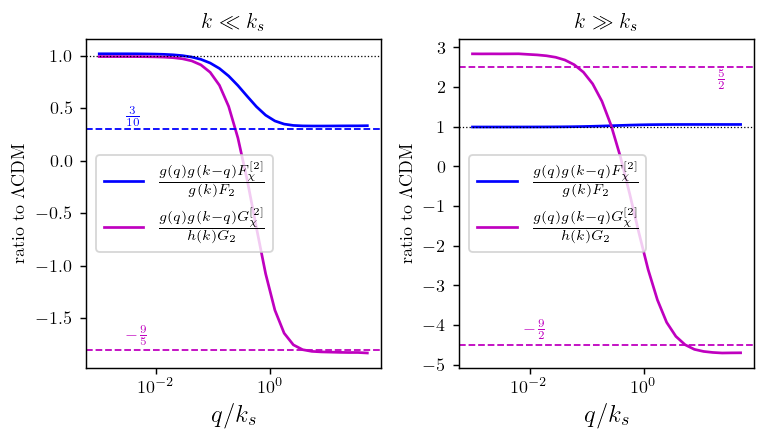

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1/20
qlist=np.logspace(-3,np.log10(50),30)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,_,F2x,G2x= nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_low.append([F2x,g_numk(kplow)*nk.F2_0(kplow,qp,mup),G2x,h_numk(kplow)*nk.G2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low).T;

# First plot
ax1.plot(qlist,Flist_low[0]/Flist_low[1], 'b', label=r'$\frac{g(q)g(k-q)F_\chi^{[2]}}{g(k)F_2}$')
ax1.plot(qlist,Flist_low[2]/Flist_low[3], 'm', label=r'$\frac{g(q)g(k-q)G_\chi^{[2]}}{h(k)G_2}$')

ax1.axhline(3/10, color='b', linestyle='--', linewidth=1)
ax1.text(3.e-3, 0.38, r'$\frac{3}{10}$', color='b', fontsize=9)
ax1.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax1.axhline(-9/5, color='m', linestyle='--', linewidth=1)
ax1.text(3.e-3, -1.7, r'$-\frac{9}{5}$', color='m', fontsize=9)
ax1.set_title(r'$k\ll k_s$')
ax1.set_ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_s$', fontsize=14)
ax1.legend(fontsize=11, loc='center left')

kphigh=20
qlist=np.logspace(-3,np.log10(50),30)

Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,G2x=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2x, g_numk(kphigh)*nk.F2_0(kphigh,qp,mup), G2x, h_numk(kphigh)*nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high).T

# Second plot
ax2.plot(qlist,Flist_high[0]/Flist_high[1], 'b', label=r'$\frac{g(q)g(k-q)F_\chi^{[2]}}{g(k)F_2}$')
ax2.plot(qlist,Flist_high[2]/Flist_high[3], 'm', label=r'$\frac{g(q)g(k-q)G_\chi^{[2]}}{h(k)G_2}$')

ax2.axhline(2.5, color='m', linestyle='--', linewidth=1)
ax2.text(20, 2.1, r'$\frac{5}{2}$', color='m', fontsize=9)

ax2.axhline(-4.5, color='m', linestyle='--', linewidth=1)
ax2.text(8.e-3, -4.2, r'$-\frac{9}{2}$', color='m', fontsize=9)

ax2.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax2.legend(fontsize=11, loc='center left')
ax2.set_title(r'$k\gg k_s$')
ax2.set_xscale('log')
ax2.set_ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
ax2.set_xlabel(r'$q/k_s$', fontsize=14)
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2chi_qkMq.pdf', bbox_inches='tight')
plt.show()

/home/fverdian/anaconda3/lib/python3.10/site-packages/scipy/integrate/_odepack_py.py:248: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)


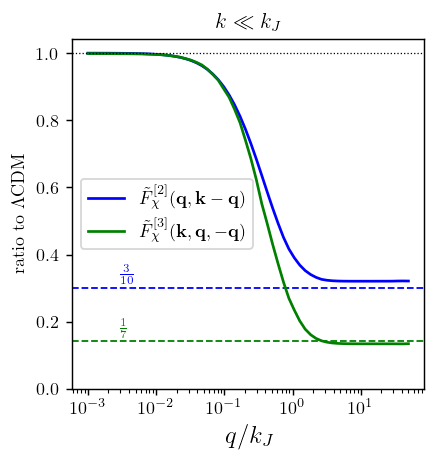

In [40]:
plt.figure(figsize=(3.5, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-3
qlist=np.logspace(-3,np.log10(50),60)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,_,F2x,_= nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_low.append([F2x,nk.F2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
plt.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'b', label=r'$\tilde F_\chi^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
F2chi_qkMq_limB = 3/10
plt.axhline(F2chi_qkMq_limB, color='b', linestyle='--', linewidth=1)
plt.text(3.e-3, 0.33, r'$\frac{3}{10}$', color='b', fontsize=9)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-4
qlist=np.logspace(-3,np.log10(50),60)
F3list_low=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    F3c,_,F3x,_=nk.solve_F3([kplow,qp,mup], return_timedep=False)
    F3list_low.append([F3x/g_ank(kplow),nk.F3_0(kplow,qp,mup)])
F3list_low=np.array(F3list_low).T;

# Second plot
plt.plot(qlist,F3list_low[0]/F3list_low[1], 'g', label=r'$\tilde F_\chi^{[3]}(\mathbf{k},\mathbf{q},-\mathbf{q})$')
plt.axhline(1/7, color='g', linestyle='--', linewidth=1)
plt.text(3.e-3, 0.17, r'$\frac{1}{7}$', color='g', fontsize=9)


plt.axhline(1, color='k', linestyle=':', linewidth=0.7)
plt.legend()
plt.ylim([0.,None])
plt.title(r'$k\ll k_J$')
plt.ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
plt.xscale('log')
plt.xlabel(r'$q/k_J$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F23chi.pdf', bbox_inches='tight')
plt.show()